## Machine Learning – Prédiction du prix des billets d’avion ##

### Analyse Exploratoire des Données ##

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


##### Importation et chargement de dataset #####

In [135]:
df = pd.read_csv('Clean_Dataset.csv')
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


##### Analyse technique des variables #####


In [136]:
df.dtypes

Unnamed: 0            int64
airline              object
flight               object
source_city          object
departure_time       object
stops                object
arrival_time         object
destination_city     object
class                object
duration            float64
days_left             int64
price                 int64
dtype: object

 | Variable         | Type                                     |
| ---------------- | ----------------------------------------- |
| price            | Continue                                  |
| duration         | Continue                                  |
| days_left        | Continue                                  |
| stops            | Discrète                                  |
| airline          | Catégorielle nominale                     |
| flight           | Catégorielle nominale                     |
| source_city      | Catégorielle nominale                     |
| destination_city | Catégorielle nominale                     |
| class            | Catégorielle nominale                     |
| departure_time   | Ordinale                                  |
| arrival_time     | Ordinale                                  |


In [137]:
df = df.drop(columns= 'Unnamed: 0')

In [138]:
df.isnull().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [139]:
df.duplicated().sum()

np.int64(0)

##### Analyse univariée #####


##### 1. Nombre de vols par compagnie #####

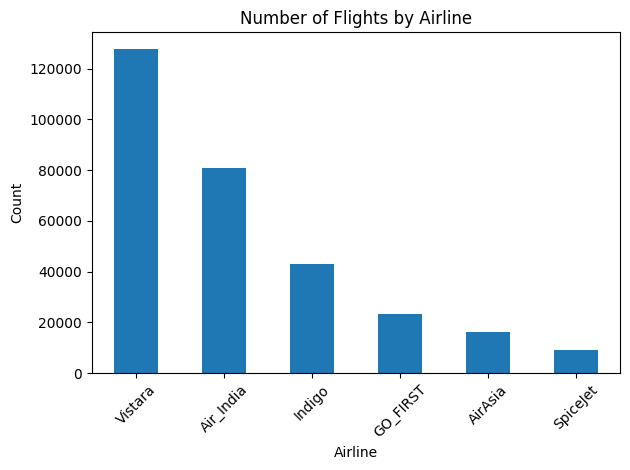

In [140]:
plt.figure()

df["airline"].value_counts().plot(kind="bar")

plt.xticks(rotation=45)
plt.title("Number of Flights by Airline")
plt.xlabel("Airline")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

##### 2. Nombre de vols par ville origine/destination  #####

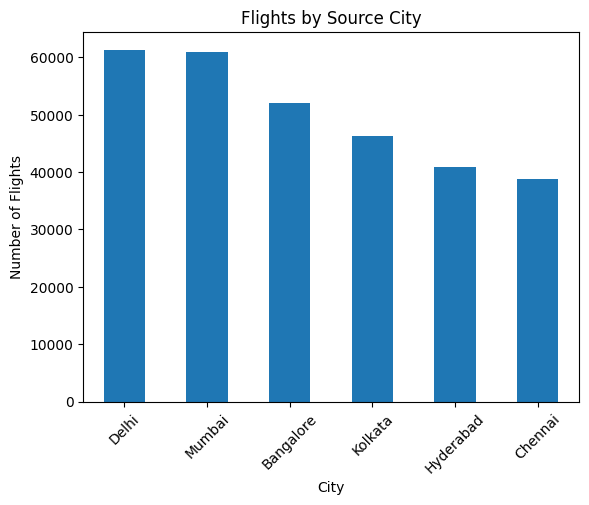

In [141]:
plt.figure()

df['source_city'].value_counts().plot(kind="bar")
plt.xticks(rotation=45)
plt.title("Flights by Source City")
plt.xlabel("City")
plt.ylabel("Number of Flights")

plt.show()

##### 3. Distribution des arrêts  #####

[Text(0, 3, '250863'), Text(0, 3, '36004'), Text(0, 3, '13286')]

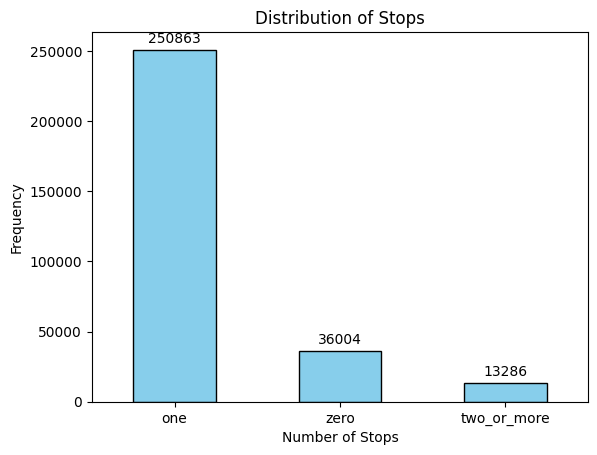

In [142]:
ax = df['stops'].value_counts().plot(kind="bar", color="skyblue", edgecolor="black", rot=0)
ax.set_title("Distribution of Stops")
ax.set_xlabel("Number of Stops")
ax.set_ylabel("Frequency")
ax.bar_label(ax.containers[0], padding=3)

##### 4. Distribution par temps d'arrivée  #####

Text(0.5, 1.0, 'Arrival Traffic Distribution')

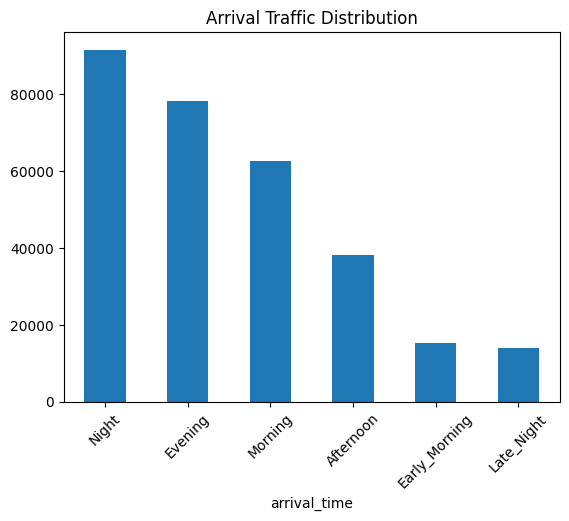

In [143]:
plt.figure()
df['arrival_time'].value_counts().plot(kind="bar")
plt.xticks(rotation=45)
plt.title("Arrival Traffic Distribution")

##### 5. Distribution de vols par ville de destination  #####

Text(0.5, 1.0, 'Distribution of Destination Cities')

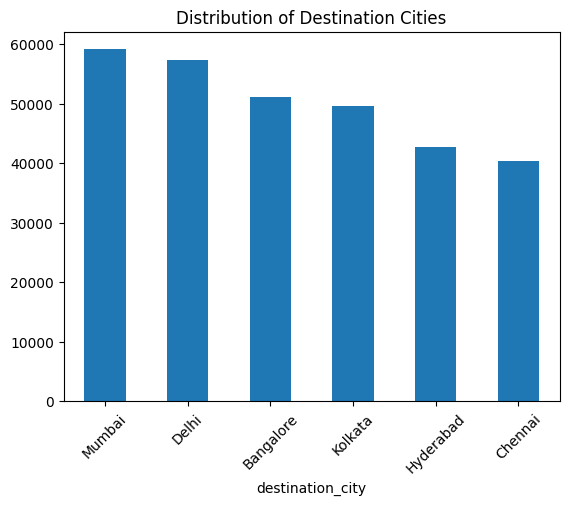

In [144]:
plt.figure()
df['destination_city'].value_counts().plot(kind="bar")
plt.xticks(rotation=45)
plt.title("Distribution of Destination Cities")

##### 6. Distribution de vols par classe #####

Text(0.5, 1.0, 'Flight Distribution by Ticket Class')

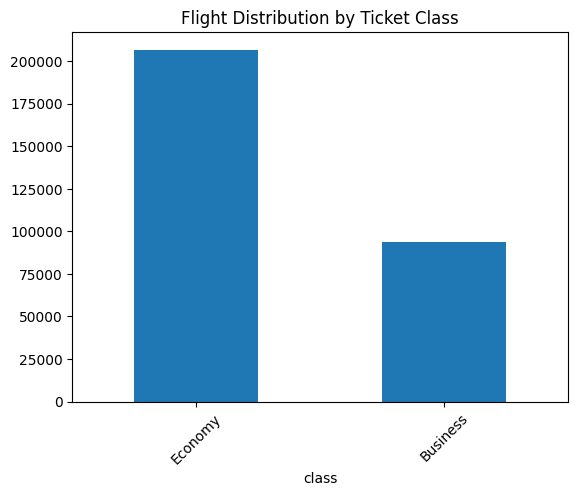

In [145]:
plt.figure()
df['class'].value_counts().plot(kind="bar")
plt.xticks(rotation=45)
plt.title("Flight Distribution by Ticket Class")

##### 7. Distribution de vols par durée #####

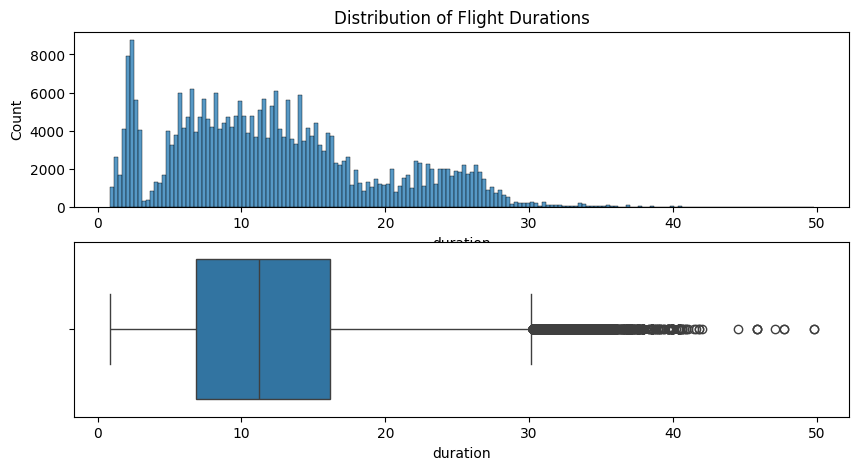

In [146]:
plt.figure(figsize=(10,5))
plt.subplot(211)
sns.histplot(data=df,x='duration')
plt.title("Distribution of Flight Durations")
plt.subplot(212)
sns.boxplot(data=df,x='duration')

plt.show()

#####


##### 8. Distribution de vols par prix des tickets #####

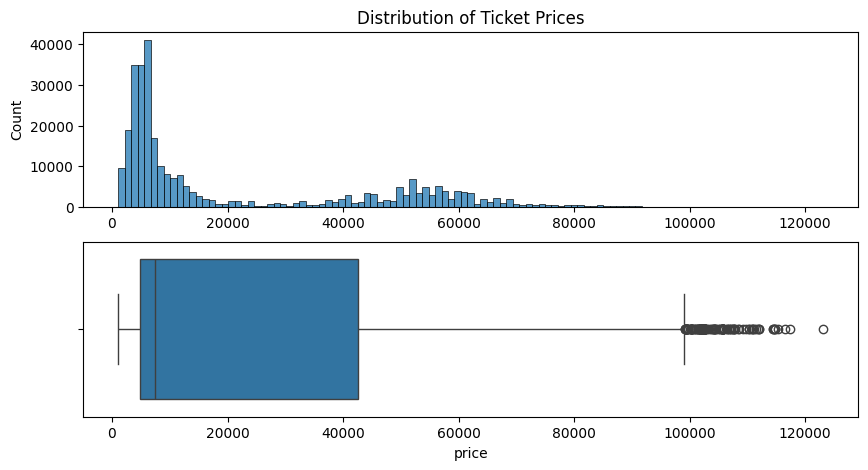

In [147]:
plt.figure(figsize=(10,5))
plt.subplot(211)
sns.histplot(data=df,x='price')
plt.title("Distribution of Ticket Prices")
plt.xlabel("")
plt.subplot(212)
sns.boxplot(data=df,x='price')
plt.show()


##### Analyse Multivariée #####


##### 1. Durée du vol VS prix #####


C:\Users\asus\AppData\Local\Temp\ipykernel_8488\764659006.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("duration_bin")["price"].mean()


<Axes: xlabel='duration_bin', ylabel='price'>

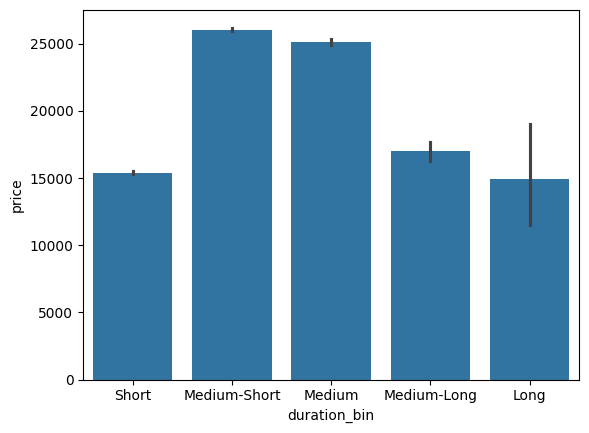

In [148]:
df["duration_bin"] = pd.cut(df["duration"], bins=5, labels=["Short", "Medium-Short", "Medium", "Medium-Long", "Long"])
df.groupby("duration_bin")["price"].mean()
sns.barplot(x="duration_bin", y="price", data=df)


##### 2. Compagnie Aérienne VS prix #####


Text(0, 0.5, 'Prix (USD)')

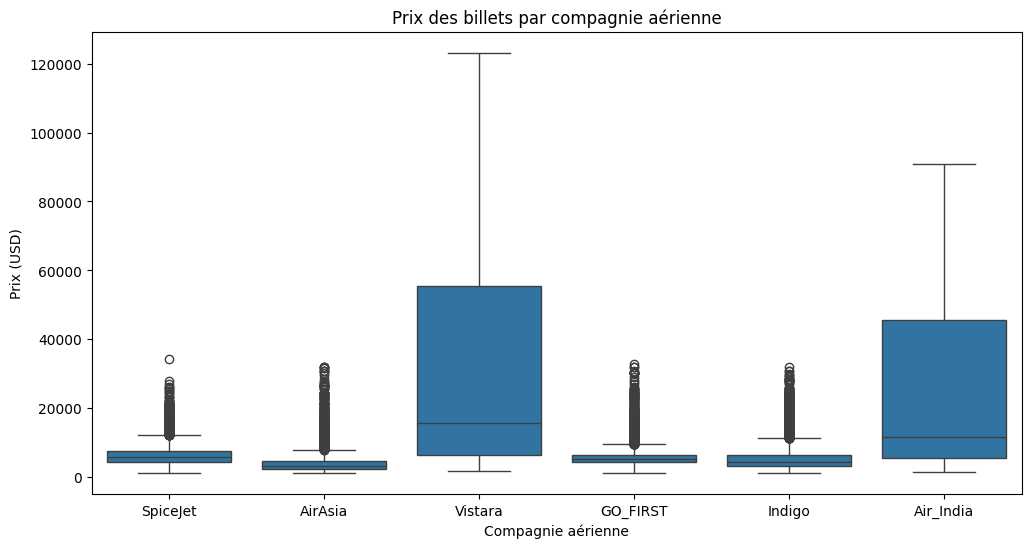

In [149]:
plt.figure(figsize=(12,6))
df.groupby('airline')['price'].mean().sort_values(ascending=False)
sns.boxplot(x='airline', y='price', data=df)
plt.title('Prix des billets par compagnie aérienne')
plt.xlabel('Compagnie aérienne')
plt.ylabel('Prix (USD)')

##### 3. Nombre d'Escales VS prix #####


Text(0, 0.5, 'Prix (USD)')

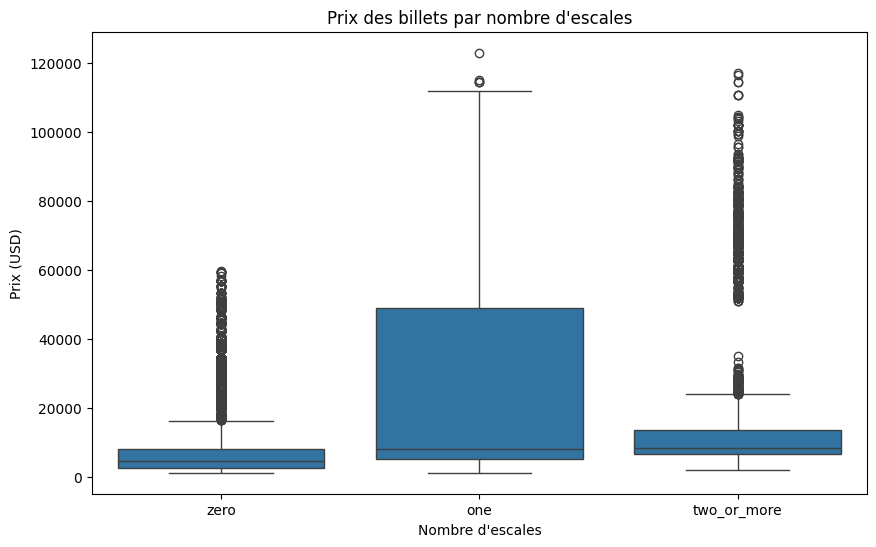

In [150]:
plt.figure(figsize=(10,6))
sns.boxplot(x='stops', y='price', data=df)
plt.title('Prix des billets par nombre d\'escales')
plt.xlabel('Nombre d\'escales')
plt.ylabel('Prix (USD)')


##### 4. Jours avant vol VS prix / par compagnie #####


C:\Users\asus\AppData\Local\Temp\ipykernel_8488\340578772.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('days_before_flight_bin')['price'].mean()


Text(0, 0.5, 'Prix moyen (USD)')

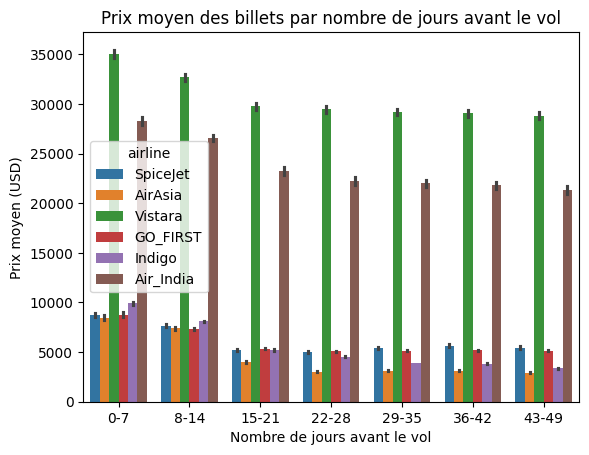

In [151]:
plt.figure()
bins = [0, 7, 14, 21, 28, 35, 42, 49]
labels = ['0-7', '8-14', '15-21', '22-28', '29-35', '36-42', '43-49']
df['days_before_flight_bin'] = pd.cut(df['days_left'], bins=bins, labels=labels)
df.groupby('days_before_flight_bin')['price'].mean()
sns.barplot(x='days_before_flight_bin', y='price', data=df,hue='airline')
plt.title('Prix moyen des billets par nombre de jours avant le vol')
plt.xlabel('Nombre de jours avant le vol')
plt.ylabel('Prix moyen (USD)')
